# Exploratory Data Analysis: Part 2
<font color=red>Compared to `EDA_Part1.ipynb`, this section will focus on our prediction target: the investigation of `responder_6` to uncover more information that will be useful for subsequent model setup.

In [1]:
import pandas as pd
import numpy as np
import gc
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, PercentFormatter, FuncFormatter
import seaborn as sns
import glob
import statsmodels.api as sm

import logging
import warnings
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

from scipy.stats import jarque_bera, probplot


In [2]:
# Some initial configurations
def percentage_formatter(x, _):
    return f"{x * 100:.0f}%"

target_variable = 'responder_6'

In [3]:
class CONFIG:
    seed = 666
    path = "../data/"
    save_path = 'result/'


class SpecialCols:
    date_id = "date_id"
    time_id = "time_id"
    symbol_id = "symbol_id"
    weight_col = "weight"
    id_cols = [date_id, time_id, symbol_id]
    target_col = "responder_6"
    target_cols = ["responder_%d" % i for i in range(9)]

Considering that different partitions within the `train.parquet` file may contain variations, during this data concatenation process, we extract and retain the partition number from which each observation originates.

In [4]:
class DataProcessor:
    def __init__(self, ts_window=100) -> None:
        logger.info("data preparing")
        self._data_path = os.path.join(CONFIG.path, "train.parquet/**/*.parquet")  # Use the glob pattern to match all partitions.
        self._data = None

        # get all partition file path in order
        self._parquet_files = sorted(glob.glob(self._data_path, recursive=True))
        
        # select columns
        columns_to_read = SpecialCols.id_cols + [SpecialCols.target_col]  

        # initially empty DataFrame to store data from all partitions
        for i, file_path in enumerate(self._parquet_files):
            # read the current partition's Parquet file
            partition_data = pl.read_parquet(file_path,columns=columns_to_read)

            # add partition_id column to the current partition's data
            partition_data = partition_data.with_columns(pl.lit(i).alias("partition_id"))

            # if it's the first partition, initialize self._data, otherwise merge the data
            if self._data is None:
                self._data = partition_data
            else:
                self._data = self._data.vstack(partition_data)

        self._data = self._data.with_columns([pl.col(SpecialCols.id_cols)])  # set index

        # get time_id and symbol_id columns
        self._data = self._data.with_columns([
            pl.col(SpecialCols.time_id).alias("time_id_col"),
            pl.col(SpecialCols.symbol_id).alias("symbol_id_col")
        ])
        # print('test')
        self._ts_window = ts_window
        
        # get lag 1
        self._data = (
            self._data
            .with_columns(
                [pl.col(c).shift(1).over([SpecialCols.time_id, SpecialCols.symbol_id]).alias(f"{c}_lag_1") for c in [SpecialCols.target_col]] # only for target_col
            )
        )
        
        gc.collect()
        logger.info("start computing")

In [5]:
dp = DataProcessor()
sample_df=dp._data
sample_df

INFO:root:data preparing
INFO:root:start computing


date_id,time_id,symbol_id,responder_6,partition_id,time_id_col,symbol_id_col,responder_6_lag_1
i16,i16,i8,f32,i32,i16,i8,f32
0,0,1,0.775981,0,0,1,null
0,0,7,0.703665,0,0,7,null
0,0,9,2.109352,0,0,9,null
0,0,10,1.114137,0,0,10,null
0,0,14,-3.57282,0,0,14,null
…,…,…,…,…,…,…,…
1698,967,34,-0.132337,9,967,34,-0.045938
1698,967,35,-0.249584,9,967,35,0.167733
1698,967,36,-0.065355,9,967,36,-0.109359


## Responder 6's distribution
### Important Premise

In the previous notebook, it has been confirmed that all `responder` values have no missing data. This means that the focus of observation here, `responder_6`, does not contain any null values.

### This Section

This section will carry out distribution visualization and normality testing.

In [6]:
useful = [target_variable, 'partition_id']

# plot utils
min_target = sample_df.select([target_variable]).min().item()
max_target = sample_df.select([target_variable]).max().item()
quant_975 = sample_df.select([target_variable]).quantile(.975).item()
quant_025 = sample_df.select([target_variable]).quantile(.025).item()

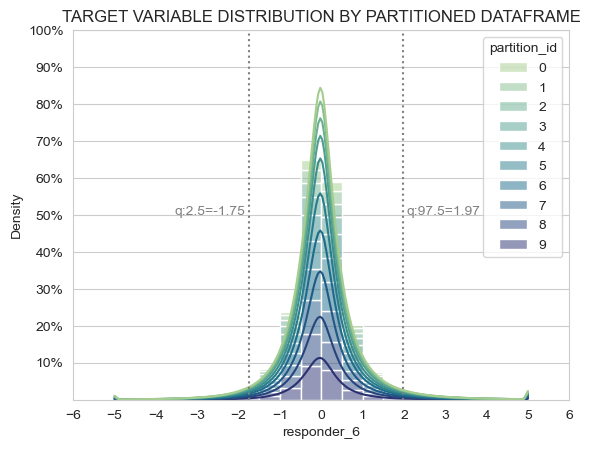

In [7]:
xticks = np.arange(min_target-1, max_target+2, 1)
yticks = np.arange(0.1, 1.1, 0.1)
formatter = FuncFormatter(percentage_formatter)

# plot
g = sns.histplot(
    x=target_variable, hue='partition_id', data=sample_df.select(useful),
    multiple='stack', kde=True, bins=20, stat='density', palette='crest')

# formatting
g.set_title('Target variable distribution by partitioned dataframe'.upper())
g.set_xticks(xticks)
g.set_yticks(yticks)
g.yaxis.set_major_formatter(formatter)
g.axvline(x=quant_975, color='gray', linestyle='dotted')
g.axvline(x=quant_025, color='gray', linestyle='dotted')
g.text(quant_975*1.05, 0.5, f'q:97.5={round(quant_975, 2)}', color='gray', ha='left')
g.text(quant_025*1.05, 0.5, f'q:2.5={round(quant_025, 2)}', color='gray', ha='right')

g.grid(False, axis='x')
g.grid(True, axis='y')
plt.show()


In [8]:
# Statistical test for normality
stat, p_value = jarque_bera(sample_df.select([target_variable]).to_numpy())
print(f"Jarque-Bera Test Statistic: {stat}, p-value: {p_value}")
if p_value > 0.05:
    print("Fail to reject the null hypothesis: Data is normally distributed.")
else:
    print("Reject the null hypothesis: Data is not normally distributed.")

Jarque-Bera Test Statistic: 94234754.8099877, p-value: 0.0
Reject the null hypothesis: Data is not normally distributed.


In [9]:
quant_025

-1.7535574436187744

In [10]:
quant_975

1.9683572053909302

#### Distribution Notes

Our initial observations reveal a certain level of symmetry in the distribution, with a mean approximately centered around zero. The 95% range of values provided by `responder_6` falls between -1.75 and 1.96. 

Additionally, we notice the presence of long tails, a characteristic feature often observed in financial market data.

To assess whether the distribution conforms to normality, we conducted the Jarque-Bera test, which indicated that the distribution is not normal.

Furthermore, it's evident that the distribution of data varies across different partitions. This observation leads us to conclude:

- Training on the full sample might not be appropriate due to differing data distributions.
- Implementing online learning becomes essential (when in competition); otherwise, model performance will likely deteriorate over time. This is because even within the training set, there are noticeable differences in data distribution, suggesting that static models may quickly become outdated as new data comes in.

### Target variable through date and time¶


In [11]:
# rank by date_id and time_id
df_sorted = sample_df.sort(['date_id', 'time_id'])
# add a new column 'idx_col' containing an integer sequence starting from 0
df_sorted = df_sorted.with_columns(pl.arange(0, df_sorted.height).alias('idx_col'))
# convert Polars DataFrame to Pandas DataFrame for plotting with seaborn
df_pandas = df_sorted.to_pandas()

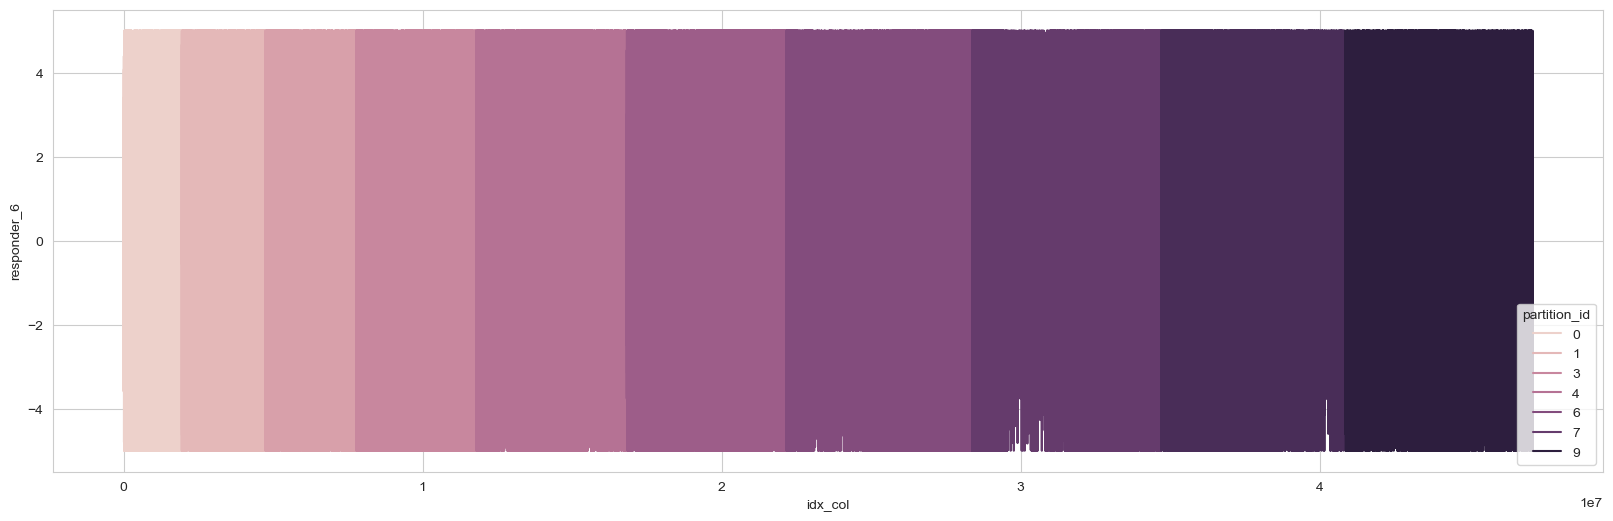

In [12]:
# set the size of the figure
plt.figure(figsize=(20, 6)) 

g = sns.lineplot(
    data=df_pandas,
    x='idx_col',
    y=target_variable,
    hue='partition_id'
)

plt.show()

#### Distribution Consistency Across Partitions

The layout here is relatively dense, indicating a high level of consistency across each partition. Upon closer inspection, it appears that the distributions within most partitions are quite similar.

This observation suggests a degree of uniformity in how data is spread across different segments, despite the noted variations in earlier sections. However, while the visual density might imply similarity, it's important to continue validating these patterns with statistical tests to ensure that our model assumptions remain robust.

### Time Analysis

Let's examine the average of our target variable (`responder_6`) along with its standard deviation across different `time_id`s throughout the day, considering all partitions.

#### Objective

The primary aim here is to investigate whether `responder_6` exhibits any variations during different time intervals within a single day. By analyzing the mean and standard deviation of `responder_6` over `time_id`, we can gain insights into how this target variable behaves over the course of the day and identify any potential patterns or anomalies that occur at specific times.

<Figure size 1200x600 with 0 Axes>

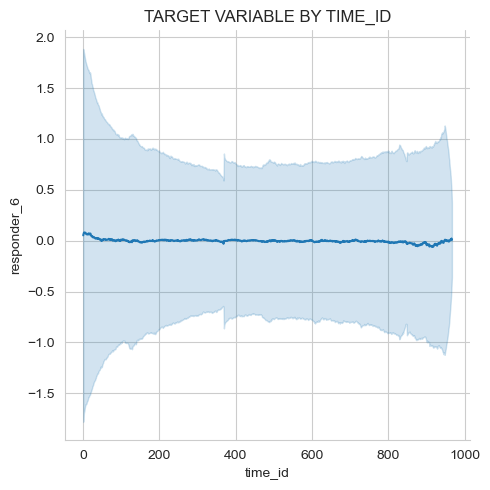

In [13]:
# set the size of the figure
plt.figure(figsize=(12, 6))

t = sns.relplot(
    data=sample_df,
    x='time_id',
    y=target_variable,
    legend=True,
    kind='line',
    errorbar='sd'
)

ax = plt.gca()
ax.set_title('Target variable by time_id'.upper())
plt.tight_layout()
plt.show()


Apparently, there is increased volatility at the beginning and end of each trading day. Additionally, the averages tend to be higher at the start of the day and gradually decrease toward the end.


Does this pattern of higher volatility and declining averages occur consistently across all partitions? Let's investigate this further to determine if these trends are universal or if they are mainly driven by a specific partition.

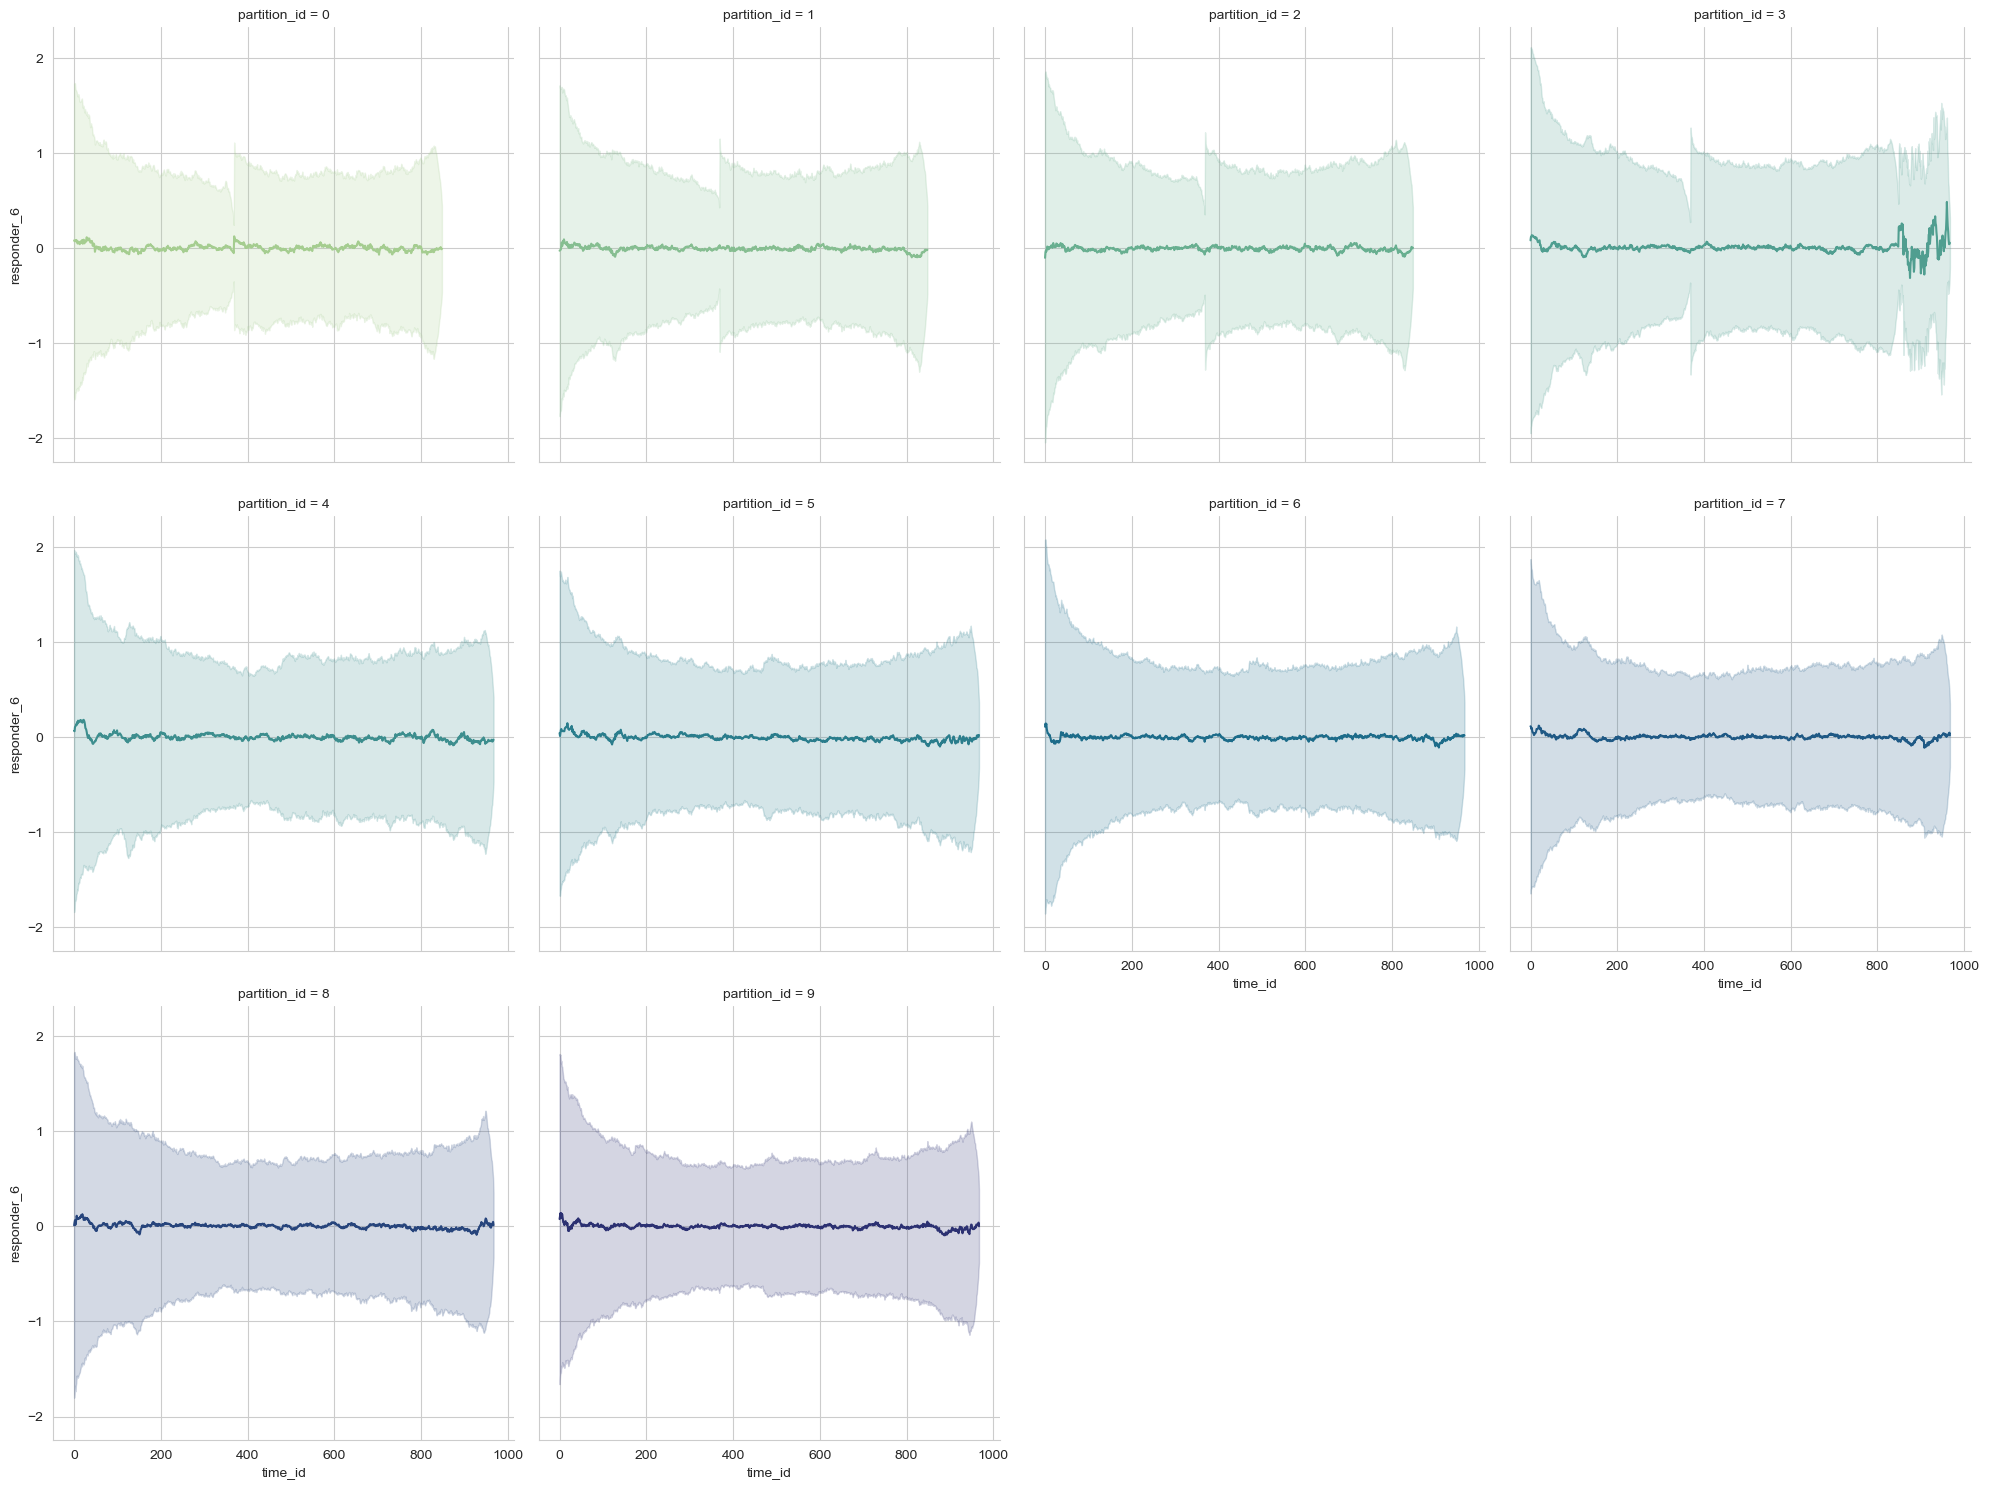

In [14]:
t1 = sns.relplot(
    data=sample_df,
    x='time_id',
    y=target_variable,
    col='partition_id',
    hue='partition_id',
    legend=False,
    kind='line',
    col_wrap=4,
    errorbar='sd',
    palette='crest'
)
plt.show()

We can observe that:

- The first three partitions contain fewer records compared to the rest.
- `Partition 3` exhibits significant volatility in its averages during about the last 200 `time_ids`.
- Despite these differences, the pattern of volatility remains consistent across all partitions.

These observations suggest that while there is a general consistency in how volatility manifests throughout the day, specific partitions may have unique characteristics that could influence model training and performance. 



Let's revisit the day when changes in trading moments were identified in `EDA_Part1.ipynb`. It is clear that this change occurred on day 667.

In [15]:
train_time_id_max_df = (sample_df
             .group_by(pl.col("date_id",'partition_id'))
             .agg([pl.col("time_id").max().alias("max_time_id")])
             .sort("date_id"))
train_time_id_max_df

date_id,partition_id,max_time_id
i16,i32,i16
0,0,848
1,0,848
2,0,848
3,0,848
4,0,848
…,…,…
1694,9,967
1695,9,967
1696,9,967


In [16]:
diff_df = train_time_id_max_df.with_columns(pl.col("max_time_id").diff().alias("diff_max_time_id"))
change_rows = diff_df.filter(pl.col("diff_max_time_id") != 0)
change_date_ids = change_rows.select(["date_id",'partition_id'])
change_date_ids # 第677天发生了time_id转变

date_id,partition_id
i16,i32
677,3


 <font color=red>Notably, day 677 falls within `partition_id=3`, which corroborates our previous findings. Therefore, it is recommended to use data from `partition_id=4` onwards for training purposes, as these partitions are less likely to be influenced by the transition period.



To gain deeper insights into this behavior, let’s **divide the `time_id` variable into 10 equal parts** and examine whether this pattern becomes more apparent.

In [17]:
gc.collect()

274

In [18]:
# generate bins
time_id_min = sample_df.select(pl.col("time_id").min()).to_series().item()
time_id_max = sample_df.select(pl.col("time_id").max()).to_series().item()
bins = np.linspace(time_id_min, time_id_max, 11)

# use NumPy's digitize method to assign bin indices
bin_indices = np.digitize(sample_df["time_id"], bins) - 1  # minus 1 to start the bin index from 0

#add the bin indices to the DataFrame
sample_df = sample_df.with_columns(pl.Series(name="time_id_bin_idx", values=bin_indices))

sample_df

date_id,time_id,symbol_id,responder_6,partition_id,time_id_col,symbol_id_col,responder_6_lag_1,time_id_bin_idx
i16,i16,i8,f32,i32,i16,i8,f32,i64
0,0,1,0.775981,0,0,1,null,0
0,0,7,0.703665,0,0,7,null,0
0,0,9,2.109352,0,0,9,null,0
0,0,10,1.114137,0,0,10,null,0
0,0,14,-3.57282,0,0,14,null,0
…,…,…,…,…,…,…,…,…
1698,967,34,-0.132337,9,967,34,-0.045938,10
1698,967,35,-0.249584,9,967,35,0.167733,10
1698,967,36,-0.065355,9,967,36,-0.109359,10


In [19]:
sample_df.schema

Schema([('date_id', Int16),
        ('time_id', Int16),
        ('symbol_id', Int8),
        ('responder_6', Float32),
        ('partition_id', Int32),
        ('time_id_col', Int16),
        ('symbol_id_col', Int8),
        ('responder_6_lag_1', Float32),
        ('time_id_bin_idx', Int64)])

In [20]:
# seperate by time_id_bin_idx and calculate the standard deviation
data = sample_df.group_by('time_id_bin_idx').agg(
    (pl.col(target_variable).std() * 2).alias('std_times_2')
)
data=data*2 # to each group, multiply the standard deviation by 2

In [21]:
data

time_id_bin_idx,std_times_2
f64,f64
0.0,5.296453
18.0,3.837895
6.0,2.87648
12.0,3.108942
8.0,2.959491
…,…
14.0,3.243623
2.0,3.86502
16.0,3.550891


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


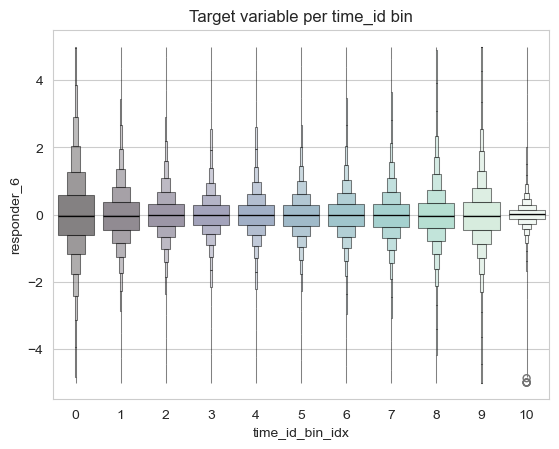

In [22]:
useful = ['time_id_bin_idx', target_variable, 'partition_id']
fig, ax = plt.subplots()

g = sns.boxenplot(
    data=sample_df[useful],
    x='time_id_bin_idx',
    y=target_variable,
    hue='time_id_bin_idx',
    palette='mako',
    legend=False,
    alpha=0.5,
    ax=ax,
)
g.set_title('Target variable per time_id bin')
plt.show()

### Adding Attributes

Before proceeding with the analysis, let's introduce several relevant variables to enhance our understanding of the data:

- **cum_target**: Given that the target variable appears to be differentiated, calculating its cumulative sum will help us observe the overall trend of responses across all partitions.
- **daily_cum_target**: Similar to `cum_target`, but this attribute accumulates the target variable separately for each `date_id`, allowing us to track daily trends independently.
- **imbalance**: This attribute captures the sign (whether positive or negative) of each recorded value in the target variable, providing insight into directional movements.
- **cum_imbalance**: The cumulative sum of the `imbalance` values, which can highlight long-term directional tendencies over time.
- **daily_cum_imbalance**: Like `cum_imbalance`, but this metric is grouped by `date_id`, offering a day-to-day view of the cumulative imbalance.

These additional attributes will provide a richer context for analyzing the behavior of the target variable and identifying any underlying patterns or anomalies within the dataset.

In [23]:
sample_df.select(pl.cum_sum("responder_6").alias('cum_target'))

cum_target
f32
0.775981
1.479646
3.588998
4.703135
1.130315
…
-100861.671875
-100861.921875
-100861.984375


In [24]:
sample_df.select(
    pl.col(target_variable).cum_sum().alias('cum_target')
) # same as above

cum_target
f32
0.775981
1.479646
3.588998
4.703135
1.130315
…
-100861.671875
-100861.921875
-100861.984375


In [25]:
# cum_target
sample_df = sample_df.with_columns(
    pl.col(target_variable).cum_sum().alias('cum_target')
)


# cum_daily_target
sample_df = sample_df.with_columns(
    pl.col(target_variable).cum_sum().over('date_id').alias('cum_daily_target')
)

# imbalance
sample_df = sample_df.with_columns(
    pl.lit(np.sign(sample_df[target_variable].to_numpy())).alias('imbalance')
)

# cum_imbalance
sample_df = sample_df.with_columns(
    pl.col('imbalance').cum_sum().alias('cum_imbalance')
)

# cum_daily_imbalance
sample_df = sample_df.with_columns(
    pl.col('imbalance').cum_sum().over('date_id').alias('cum_daily_imbalance')
)

In [26]:
sample_df

date_id,time_id,symbol_id,responder_6,partition_id,time_id_col,symbol_id_col,responder_6_lag_1,time_id_bin_idx,cum_target,cum_daily_target,imbalance,cum_imbalance,cum_daily_imbalance
i16,i16,i8,f32,i32,i16,i8,f32,i64,f32,f32,f32,f32,f32
0,0,1,0.775981,0,0,1,null,0,0.775981,0.775981,1.0,1.0,1.0
0,0,7,0.703665,0,0,7,null,0,1.479646,1.479646,1.0,2.0,2.0
0,0,9,2.109352,0,0,9,null,0,3.588998,3.588998,1.0,3.0,3.0
0,0,10,1.114137,0,0,10,null,0,4.703135,4.703135,1.0,4.0,4.0
0,0,14,-3.57282,0,0,14,null,0,1.130315,1.130315,-1.0,3.0,3.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1698,967,34,-0.132337,9,967,34,-0.045938,10,-100861.671875,50.573547,-1.0,-2.056934e6,-2178.0
1698,967,35,-0.249584,9,967,35,0.167733,10,-100861.921875,50.323963,-1.0,-2.056935e6,-2179.0
1698,967,36,-0.065355,9,967,36,-0.109359,10,-100861.984375,50.25861,-1.0,-2.056936e6,-2180.0


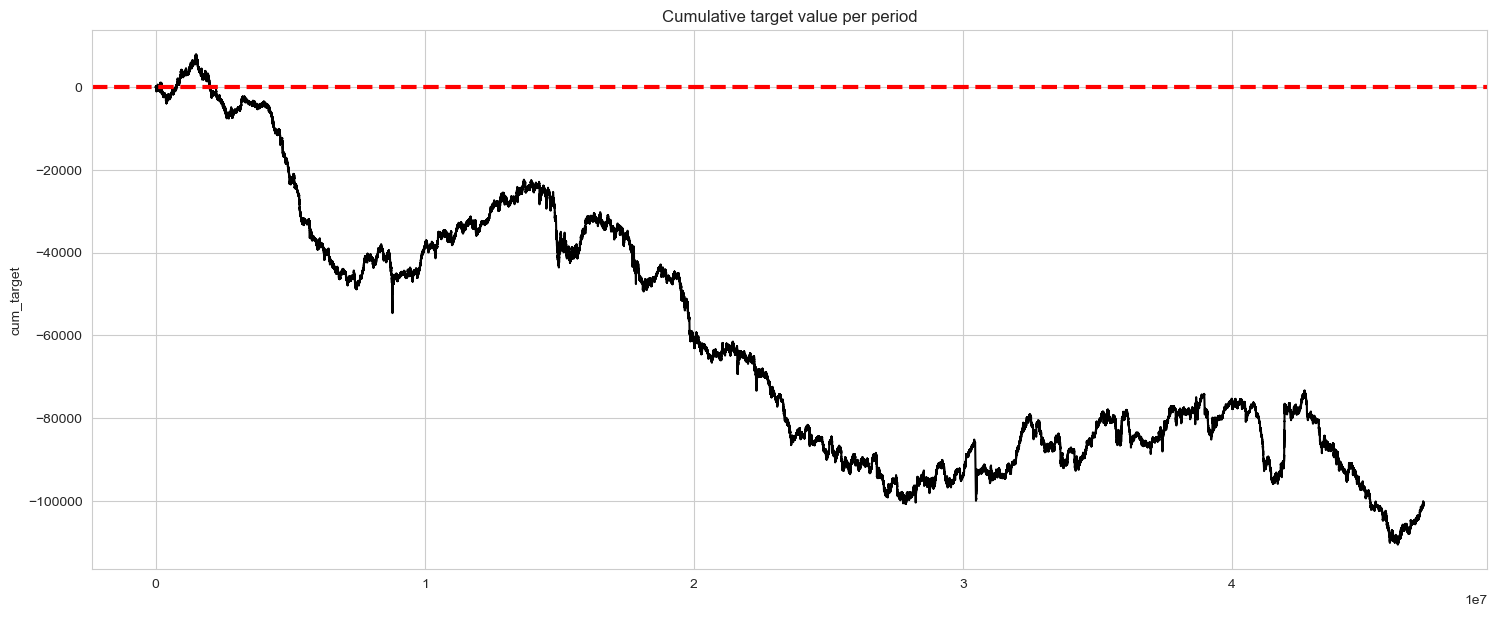

In [28]:
fig, ax = plt.subplots(figsize=(18, 7))

g = sns.lineplot(
    data=sample_df,
    x=np.arange(len(sample_df)),
    y='cum_target',
    color = 'black'
)
g.axhline(0, color='red', linestyle='dashed', linewidth=3)
g.set_title('Cumulative target value per period')
plt.show()

In [29]:
# Calculate value counts
value_counts_df = sample_df.group_by("imbalance").agg(
    pl.count("imbalance").alias("count")
)

# Normalize the counts to get proportions
total_count = sample_df.shape[0]
value_counts_df = value_counts_df.with_columns(
    (pl.col("count") / total_count).alias("proportion")
)

# Reset index by adding a sequential index column
value_counts_df = value_counts_df.with_row_count(name='index')

In [30]:
value_counts_df

index,imbalance,count,proportion
u32,f32,u32,f64
0,1.0,22535200,0.478177
1,-1.0,24592138,0.521823


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


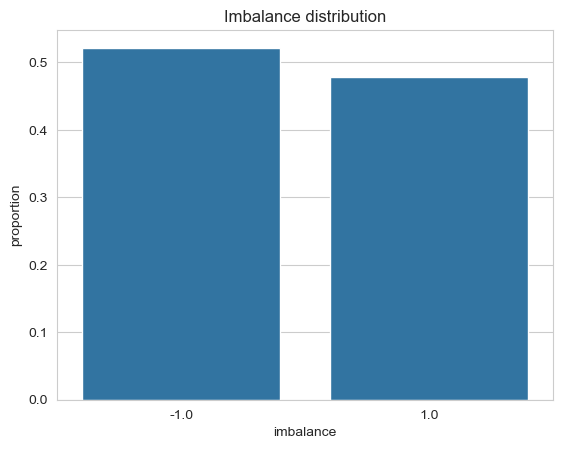

In [31]:
g = sns.barplot(
    data=value_counts_df,
    x='imbalance',
    y='proportion',
)
g.set_title('Imbalance distribution')

plt.show()

As you can see, the proportion of negative values is higher than that of positive values.

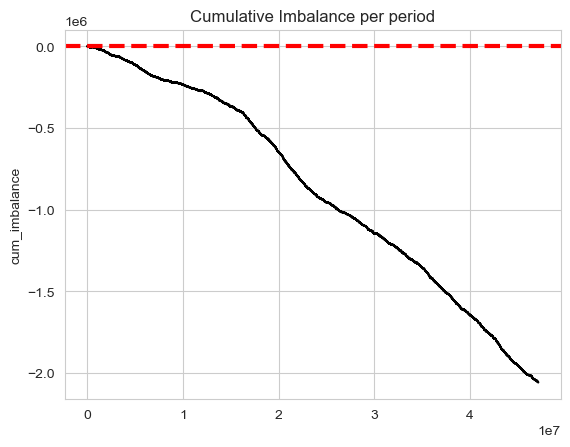

In [33]:
g = sns.lineplot(data=sample_df, x=np.arange(len(sample_df)), y='cum_imbalance',color='black')
g.axhline(0, color='red', linestyle='dashed', linewidth=3)
g.set_title('Cumulative Imbalance per period')
plt.show()

Also, the cumulative imbalance seems to be trending downwards, indicating a consistent negative imbalance across the dataset.

In [34]:
sample_df

date_id,time_id,symbol_id,responder_6,partition_id,time_id_col,symbol_id_col,responder_6_lag_1,time_id_bin_idx,cum_target,cum_daily_target,imbalance,cum_imbalance,cum_daily_imbalance
i16,i16,i8,f32,i32,i16,i8,f32,i64,f32,f32,f32,f32,f32
0,0,1,0.775981,0,0,1,null,0,0.775981,0.775981,1.0,1.0,1.0
0,0,7,0.703665,0,0,7,null,0,1.479646,1.479646,1.0,2.0,2.0
0,0,9,2.109352,0,0,9,null,0,3.588998,3.588998,1.0,3.0,3.0
0,0,10,1.114137,0,0,10,null,0,4.703135,4.703135,1.0,4.0,4.0
0,0,14,-3.57282,0,0,14,null,0,1.130315,1.130315,-1.0,3.0,3.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1698,967,34,-0.132337,9,967,34,-0.045938,10,-100861.671875,50.573547,-1.0,-2.056934e6,-2178.0
1698,967,35,-0.249584,9,967,35,0.167733,10,-100861.921875,50.323963,-1.0,-2.056935e6,-2179.0
1698,967,36,-0.065355,9,967,36,-0.109359,10,-100861.984375,50.25861,-1.0,-2.056936e6,-2180.0


### Autocorrelation

In [35]:
# sepereate by time_id_bin_idx and calculate the standard deviation
data = sample_df.group_by('time_id_bin_idx').agg(
    (pl.col(target_variable).std() * 2).alias('std_times_2')
)

In [36]:
data_means = (sample_df
              .group_by('date_id')
              .agg((pl.col(target_variable).mean())
              .alias('daily_mean')
              )
              .sort('date_id')
              ).to_pandas()

In [37]:
data_means

,date_id,daily_mean
0,0,-0.011707
1,1,-0.013778
2,2,-0.058745
3,3,-0.007691
4,4,0.033380
...,...,...
1694,1694,0.034523
1695,1695,0.033993
1696,1696,-0.010408
1697,1697,0.026231


In [38]:
data_std = (sample_df
              .group_by('date_id')
              .agg((pl.col(target_variable).std())
              .alias('daily_std')
              )
              .sort('date_id')
              ).to_pandas()

In [39]:
data_std

,date_id,daily_std
0,0,0.529894
1,1,0.812211
2,2,0.797652
3,3,0.968893
4,4,0.698249
...,...,...
1694,1694,0.670231
1695,1695,0.813060
1696,1696,0.802401
1697,1697,0.864594


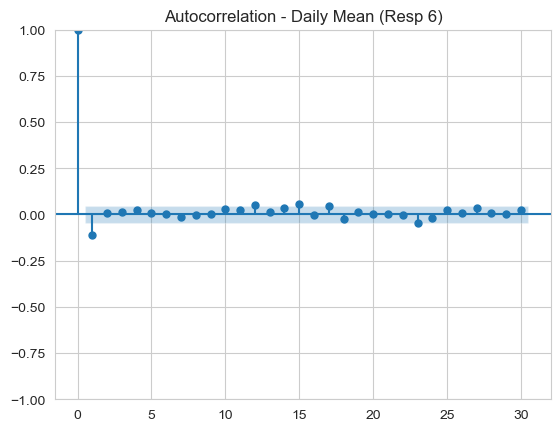

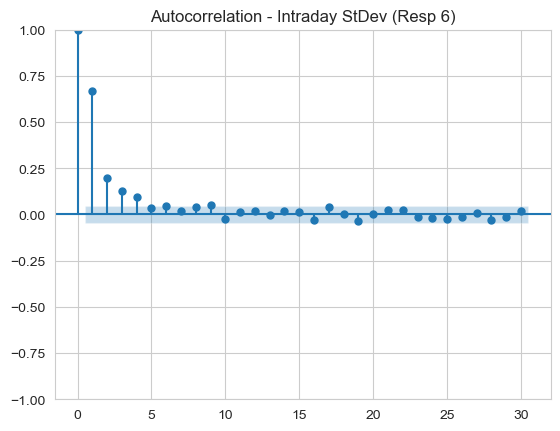

In [40]:
#Testing if there's any autocorrelation. 
sm.graphics.tsa.plot_pacf(data_means['daily_mean'].squeeze(), lags=30)
#ax[0].title="Autocorrelation - Intraday Mean (Resp 6)"
plt.title("Autocorrelation - Daily Mean (Resp 6)")
sm.graphics.tsa.plot_pacf(data_std['daily_std'].squeeze(), lags=30)
plt.title("Autocorrelation - Intraday StDev (Resp 6)")
plt.show()

<font color=red>That is, the `daily means` maintain at least some level of autocorrelation, but this does not necessarily imply that there is autocorrelation between the same `time_id` one day apart (`lag1`).</font>

**To further investigate this, let's calculate the correlation between `responder_6` and its one-day lagged version (`responder_6_1lag`).** This will help us understand whether observations at a given `time_id` on one day are predictive of observations at the same `time_id` on the following day.

By examining this correlation, we can gain insights into the temporal dependencies within the data, which could be crucial for modeling decisions. Specifically, if a significant correlation is found, *it may suggest that incorporating lag features could enhance the predictive power of our models.*

In [41]:
auto_1day = (
    sample_df
    .select(['responder_6','responder_6_lag_1'])
    .drop_nans())

auto_1day.corr()

responder_6,responder_6_lag_1
f64,f64
1.0,0.00306
0.00306,1.0


<font color=red>The linear correlation is actually quite low, especially after day 677, where there is virtually no linear correlation.</font>

In [42]:
auto_1day_677 = (
    sample_df
    .filter(pl.col("date_id") > 677) #选取发生变化后的数据
    .select(['responder_6','responder_6_lag_1'])
    .drop_nans())

auto_1day_677.corr()

responder_6,responder_6_lag_1
f64,f64
1.0,0.000868
0.000868,1.0


In [43]:
auto_1day = (
    sample_df
    .select(['responder_6','responder_6_lag_1'])
    .drop_nans()).to_pandas()

auto_1day.corr(method='spearman')

,responder_6,responder_6_lag_1
responder_6,1.00000,0.00468
responder_6_lag_1,0.00468,1.00000


In [44]:
auto_1day_677 = (
    sample_df
    .filter(pl.col("date_id") > 677) #选取发生变化后的数据
    .select(['responder_6','responder_6_lag_1'])
    .drop_nans()).to_pandas()

auto_1day_677.corr(method='spearman')

,responder_6,responder_6_lag_1
responder_6,1.000000,0.003666
responder_6_lag_1,0.003666,1.000000


Our analysis reveals that the linear correlation between `responder_6` and its one-day lagged version (`responder_6_1lag`) is not particularly strong. Particularly after day 677, the linear correlation diminishes significantly, indicating that observations at a given `time_id` on one day are not reliably predictive of observations at the same `time_id` on the following day.

Given this observation, **it suggests that incorporating a simple one-day lag feature may not provide substantial additional information for our models.** Therefore, while temporal dependencies might still exist in more complex or non-linear forms, relying solely on linear correlations with lagged variables might not be sufficient to enhance model performance.

### Supplementary Analysis

Upon examining the `symbol_id`, it becomes evident that for each symbol within a trading day, there is typically higher volatility at the opening and closing periods of the market.

For each individual `symbol_id`, we can observe that during the trading day:

- **Opening Periods**: There tends to be increased volatility as trading begins.
- **Closing Periods**: Similarly, volatility spikes as the trading day comes to an end.

These patterns suggest that the start and end of the trading session are critical times for price movements. Understanding these dynamics can be crucial for developing strategies or models that account for intra-day volatility trends, particularly around opening and closing times.

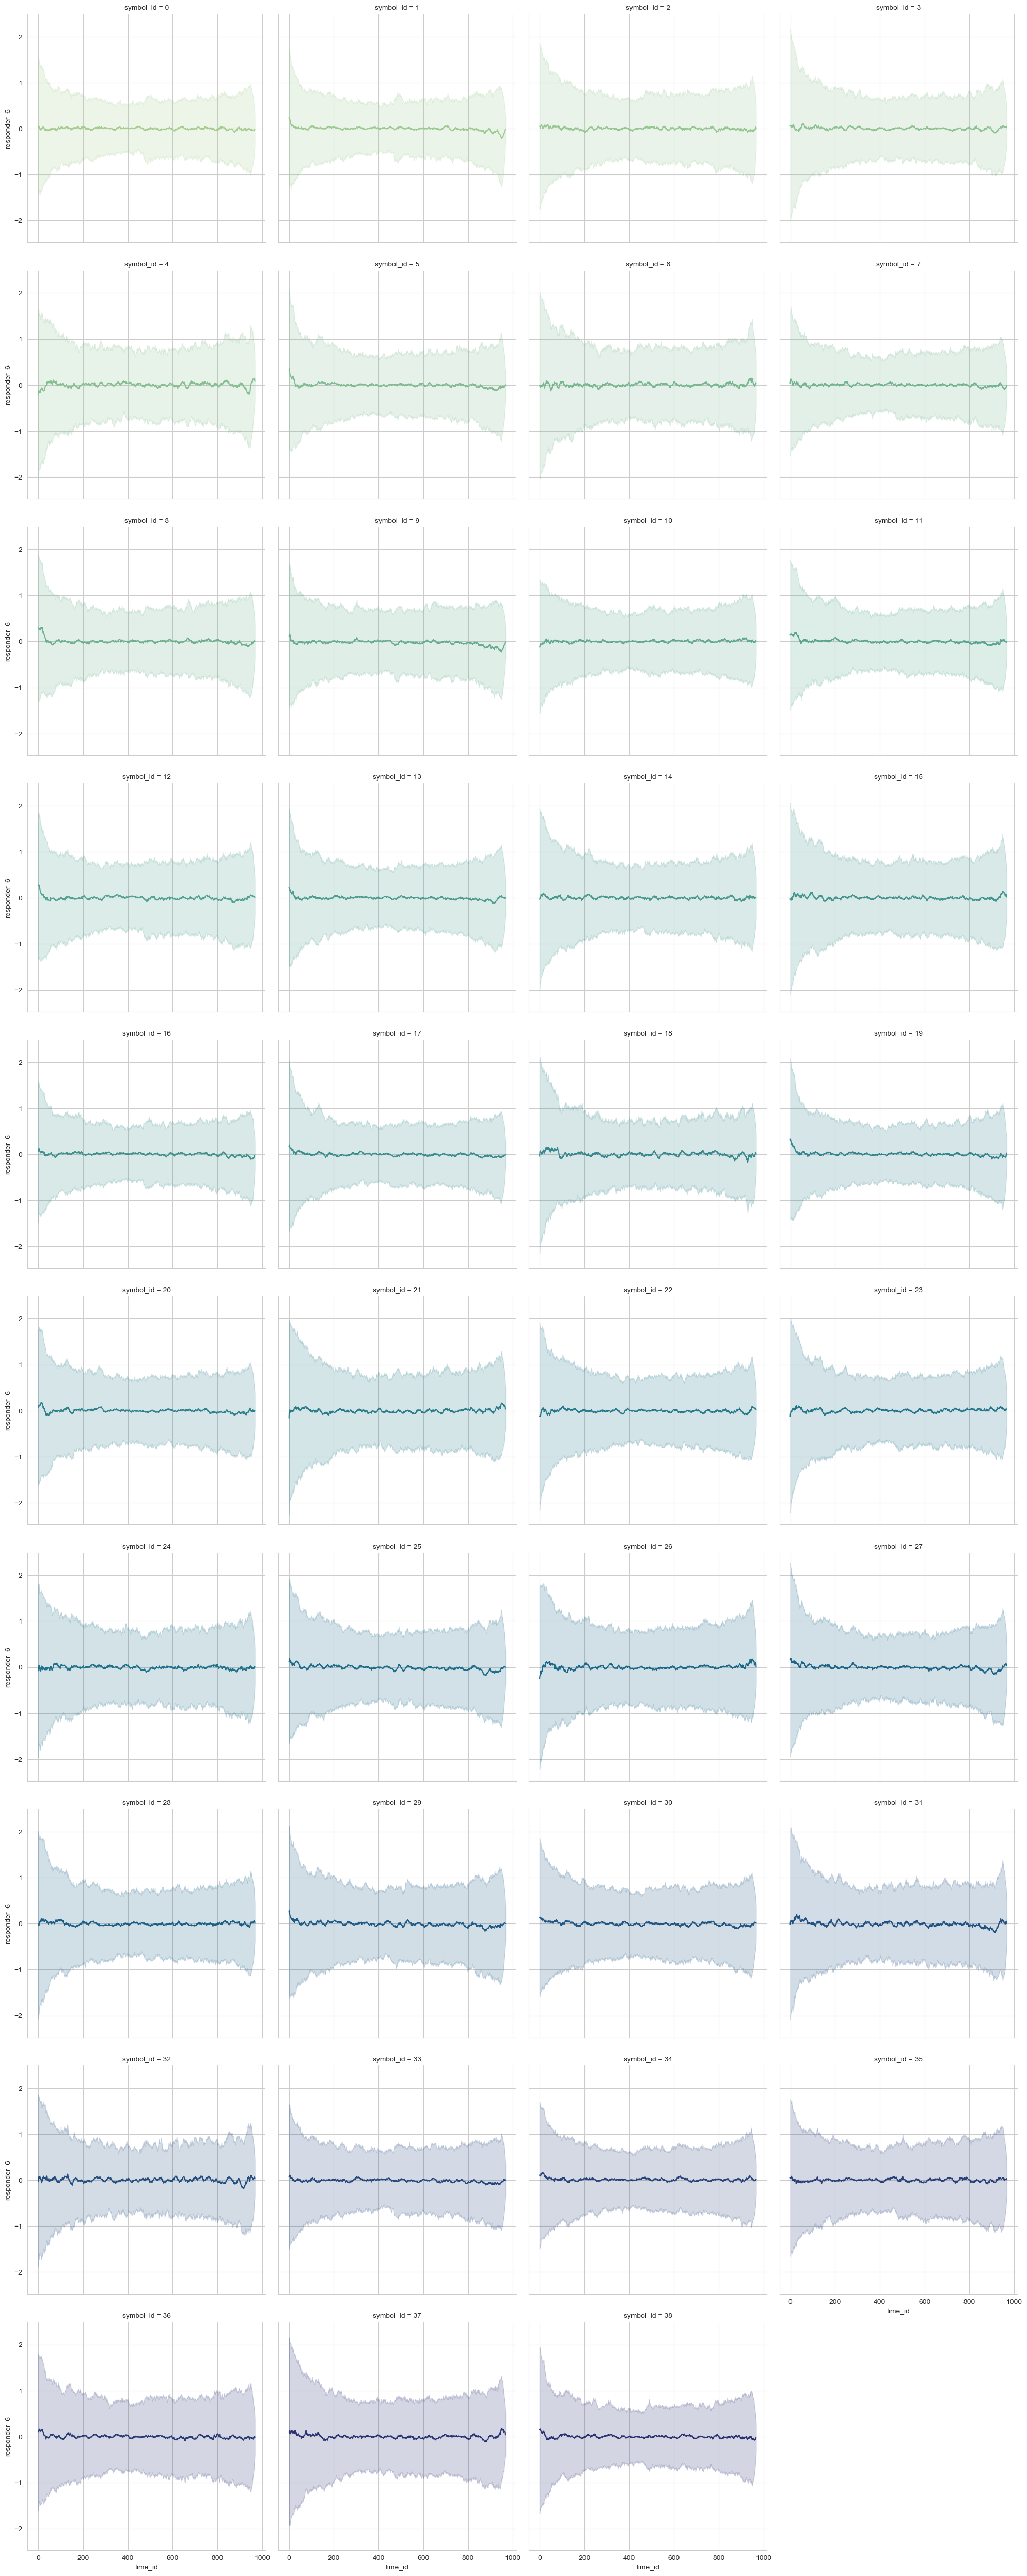

In [45]:
t1 = sns.relplot(
    data=sample_df.filter(pl.col("date_id") > 677),
    x='time_id',
    y=target_variable,
    col='symbol_id',
    hue='symbol_id',
    legend=False,
    kind='line',
    col_wrap=4,
    errorbar='sd',
    palette='crest'
)
plt.show()